In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from itertools import combinations
import json
import numpy as np

In [46]:
# Merge data from corpora
model = 'gpt-4o-mini'

datasets = []
for corpus in ['meco', 'onestop']:
    df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}.csv')
    df['corpus'] = [corpus for i in range(len(df))]
    datasets.append(df)
df = pd.concat(datasets,ignore_index=True)
df.dropna(subset=['n_triplets'], inplace=True)
df['ianum_bin'] = pd.cut(df['ianum'], bins=10)
grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),
                                                  std_triplets=('n_triplets', 'std'),
                                                  count=('ianum', 'count')).reset_index()
grouped['ianum_bin'] = grouped['ianum_bin'].astype(str)

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/4061484734.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),


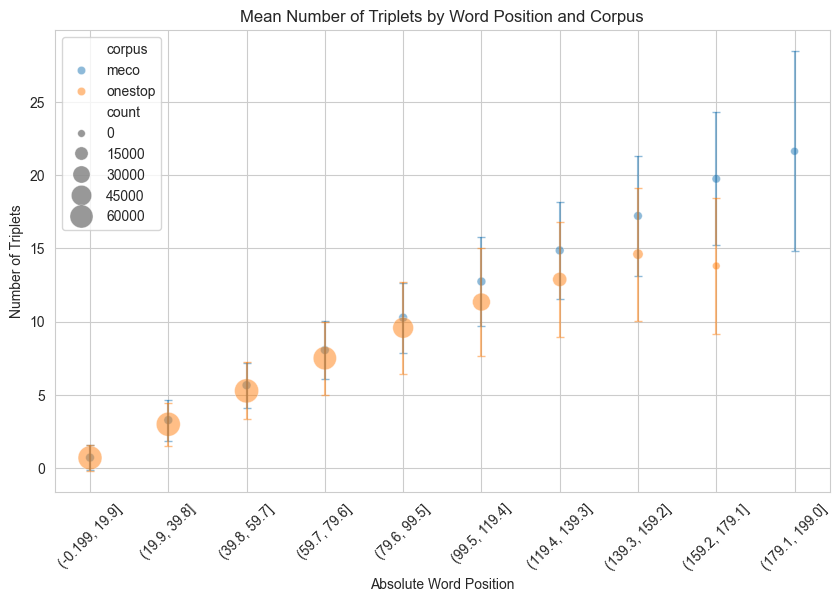

<Figure size 640x480 with 0 Axes>

In [47]:
# Number of triplets per absolute word position in text with size of dots representing data points
# df['ianum_bin'] = df.groupby('corpus')['ianum'].transform(lambda x: pd.cut(x, bins=10))
sns.set_style('whitegrid')
palette = sns.color_palette("tab10", n_colors=grouped['corpus'].nunique())
corpus_colors = dict(zip(grouped['corpus'].unique(), palette))
plt.figure(figsize=(10, 6))
graph = sns.scatterplot(data=grouped, x='ianum_bin', y='mean_triplets', size='count', hue='corpus', sizes=(30, 300), palette=corpus_colors, alpha=0.5)
for i in range(grouped.shape[0]):
    row = grouped.iloc[i]
    plt.errorbar(x=row['ianum_bin'],y=row['mean_triplets'],yerr=row['std_triplets'] if pd.notnull(row['std_triplets']) else 0,
                 fmt='none',ecolor=corpus_colors[row['corpus']],capsize=3, alpha=0.5)
plt.xticks(rotation=45)
plt.title('Mean Number of Triplets by Word Position and Corpus')
plt.xlabel('Absolute Word Position')
plt.ylabel('Number of Triplets')
# plt.tight_layout()
plt.show()
plt.clf()

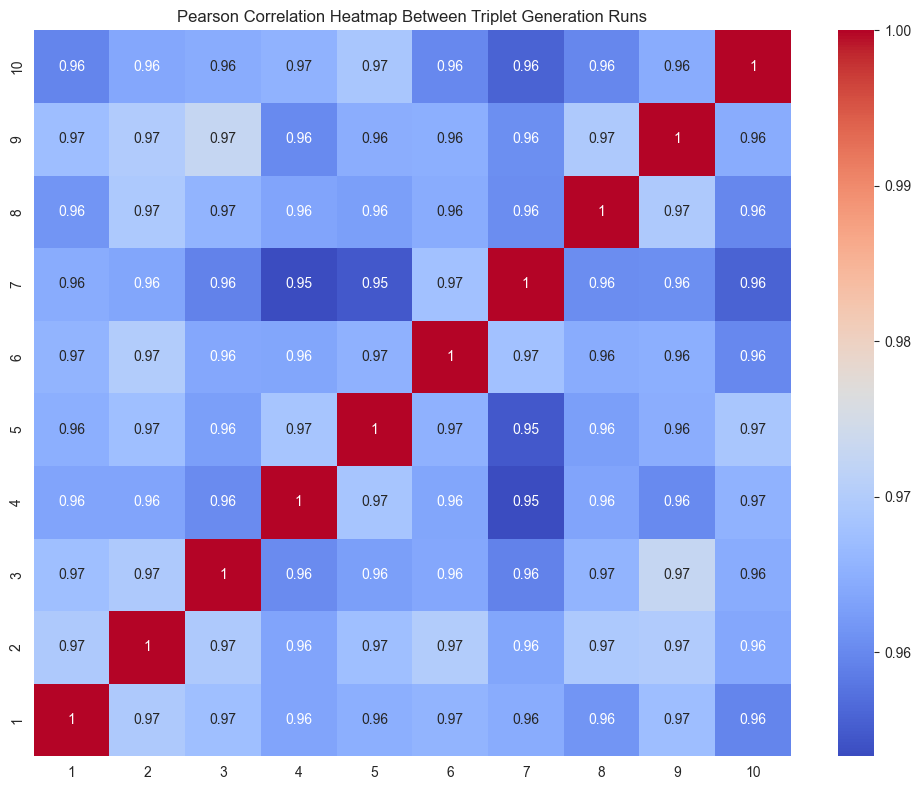

<Figure size 640x480 with 0 Axes>

In [270]:
# Check how close each run is from each other
corpus_name = 'onestop'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_{model_name}.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)

triplet_runs = []
for run_id, rows in df_corpus.groupby('run_id'):
    triplet_runs.append(rows['n_triplets'].values)

# stack data for easier processing (n_runs x n_words)
data_matrix = np.stack(triplet_runs)

# compute pairwise correlations (n_runs x n_runs)
correlation_matrix = np.corrcoef(data_matrix)

# plot correlations in heatmap
plt.figure(figsize=(10, 8))
graph = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=[f'{i}' for i in range(1, len(df_corpus['run_id'].unique())+1)], yticklabels=[f'{i}' for i in range(1, len(df_corpus['run_id'].unique())+1)])
graph.invert_yaxis()
plt.title('Pearson Correlation Heatmap Between Triplet Generation Runs')
plt.tight_layout()
plt.savefig(f'../data/analysis/{model_name}/{corpus_name}/correlation_between_runs_heatmap.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

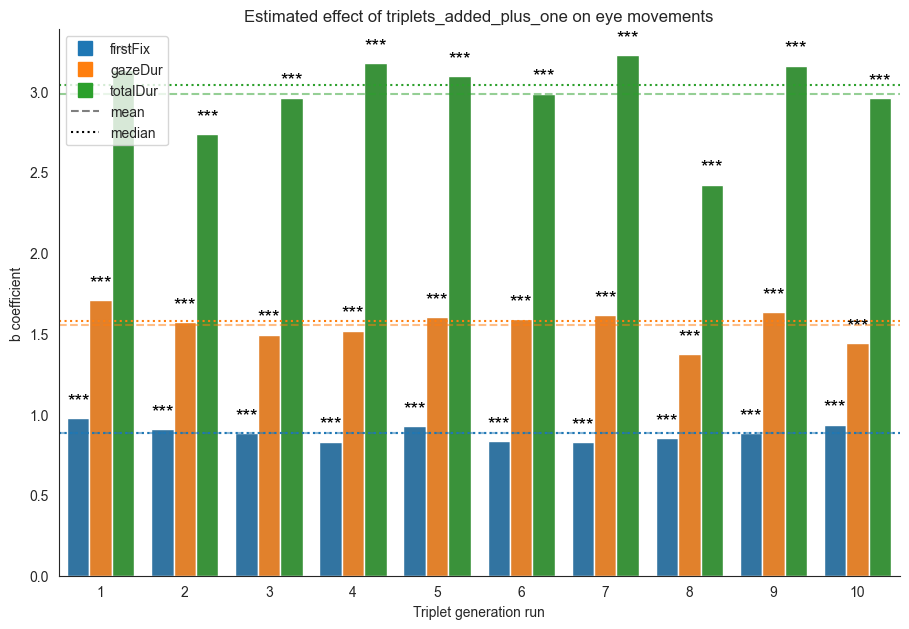

<Figure size 640x480 with 0 Axes>

In [17]:
# Beta coefficients over runs per eye mov measure
n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'
IV = 'triplets_added_plus_one' # 'n_triplets' 'norm_word_pos', 'norm_ianum', 'norm_word_pos:n_triplets', 'n_triplets:norm_ianum' 'triplets_added_plus_one' 'triplets_added_minus_one'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_type = '_plusOne' # _minusOne, _plusOne, Int, ''

coefficients, p_values, runs, eye_movs = [], [], [], []

for eye_mov_measure in DV:

    for run in range(1, n_runs+1):

        stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}{model_type}_{run}_article.csv')
        coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
        p_value =stats_df[stats_df['term']==IV]['p.value'].values[0]
        coefficients.append(coefficient)
        p_values.append(p_value)
        runs.append(run)
        eye_movs.append(eye_mov_measure)

sns.set_style('white')
# plot bars
plot_df = pd.DataFrame({'run': runs, 'coefficient': coefficients, 'p_value': p_values, 'eye_movement_measure': eye_movs})
graph = sns.catplot(data=plot_df, x=runs, y=coefficients, hue=eye_movs, kind='bar', height=6, aspect=1.5, legend=False)

# add significance asterisks
p_thresholds = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
ax = graph.ax
for bar, p_val in zip(ax.patches, plot_df['p_value']):
    significance = ''
    for threshold, symbol in [(0.001, '***'), (0.01, '**'), (0.05, '*')]:
        if p_val < threshold:
            significance = symbol
            break
    if significance:
        x = bar.get_x() + bar.get_width() / 2  # center of the bar
        y = bar.get_height() # top of the bar
        ax.text(x, y + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')

# add horizontal lines for mean and median
y_positions = {}
for i, eye_mov in enumerate(DV):
    subset = plot_df[plot_df['eye_movement_measure'] == eye_mov]
    mean_val = subset['coefficient'].mean()
    median_val = subset['coefficient'].median()
    ax.axhline(mean_val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(median_val, color=f'C{i}', linestyle=':', linewidth=1.5)
    # add secondary legend for line styles
    hue_handles = [mlines.Line2D([], [], color=f'C{i}', marker='s', linestyle='None', markersize=10, label=eye_mov) for i, eye_mov in enumerate(DV)]
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='mean', alpha=0.5)
    median_line = mlines.Line2D([], [], color='black', linestyle=':', label='median')
    # handles, labels = ax.get_legend_handles_labels()
    # handles.extend([mean_line, median_line])
    # labels.extend(['mean', 'median'])
    handles = hue_handles + [mean_line, median_line]
    labels = [eye_mov for eye_mov in DV] + ['mean', 'median']
    ax.legend(handles=handles, labels=labels)

# add extra info graph
plt.title(f'Estimated effect of {IV} on eye movements')
plt.xlabel('Triplet generation run')
plt.ylabel('b coefficient')
# plt.tight_layout()
# plt.savefig(f'../data/analysis/{model}/{corpus}/beta_coeff_runs_{model_type}_{IV}.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

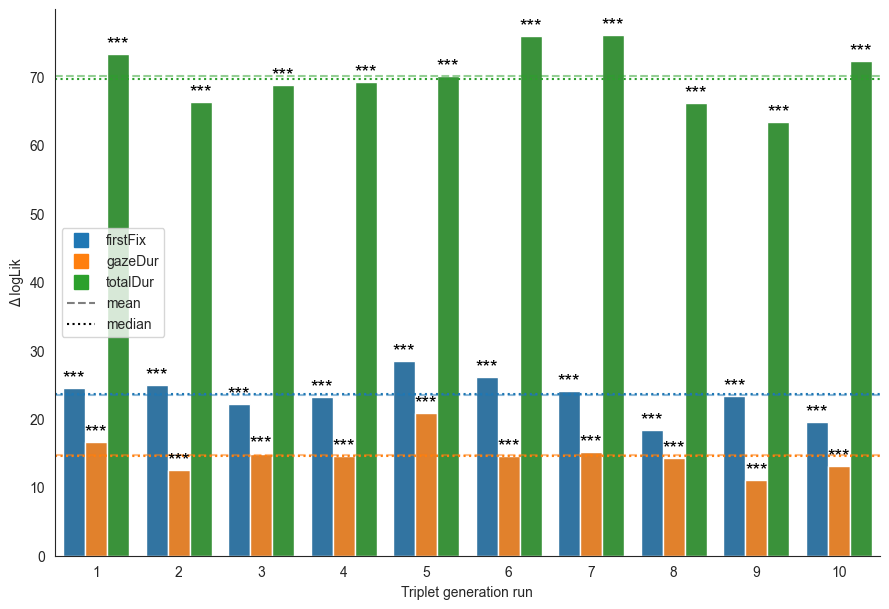

<Figure size 640x480 with 0 Axes>

In [159]:
# a graph similar to the above but with loglik, AIC and significance when comparing main model with baseline (no number of triplets)
n_runs = 10
corpus = 'meco'
model = 'gpt-4o-mini'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_type = 'Int' # _minusOne, _plusOne, Int
measure = 'logLik'  # 'logLik', 'AIC'

values, p_values, runs, eye_movs = [], [], [], []

for eye_mov_measure in DV:

    for run in range(1, n_runs+1):

        stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/anova_{eye_mov_measure}{model_type}_{run}_simple.csv')
        if measure == 'AIC':
            diff = stats_df[measure].values[0] - stats_df[measure].values[-1]
        elif measure == 'logLik':
            diff = stats_df[measure].values[-1] - stats_df[measure].values[0]
        else:
            raise ValueError(f'measure must be "AIC" or "loglik"')
        p_value = stats_df['Pr(>Chisq)'].values[-1]
        values.append(diff)
        p_values.append(p_value)
        runs.append(run)
        eye_movs.append(eye_mov_measure)

sns.set_style('white')
# plot bars
plot_df = pd.DataFrame({'run': runs, f'change-in-{measure}': values, 'p_value': p_values, 'eye_movement_measure': eye_movs})
graph = sns.catplot(data=plot_df, x=runs, y=f'change-in-{measure}', hue=eye_movs, kind='bar', height=6, aspect=1.5, legend=False)

# add significance asterisks
p_thresholds = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
ax = graph.ax
for bar, p_val in zip(ax.patches, plot_df['p_value']):
    significance = ''
    for threshold, symbol in [(0.001, '***'), (0.01, '**'), (0.05, '*')]:
        if p_val < threshold:
            significance = symbol
            break
    if significance:
        x = bar.get_x() + bar.get_width() / 2  # center of the bar
        y = bar.get_height() # top of the bar
        ax.text(x, y + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')

# add horizontal lines for mean and median
y_positions = {}
for i, eye_mov in enumerate(DV):
    subset = plot_df[plot_df['eye_movement_measure'] == eye_mov]
    mean_val = subset[f'change-in-{measure}'].mean()
    median_val = subset[f'change-in-{measure}'].median()
    ax.axhline(mean_val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(median_val, color=f'C{i}', linestyle=':', linewidth=1.5)
    # add secondary legend for line styles
    hue_handles = [mlines.Line2D([], [], color=f'C{i}', marker='s', linestyle='None', markersize=10, label=eye_mov) for i, eye_mov in enumerate(DV)]
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='mean', alpha=0.5)
    median_line = mlines.Line2D([], [], color='black', linestyle=':', label='median')
    # handles, labels = ax.get_legend_handles_labels()
    # handles.extend([mean_line, median_line])
    # labels.extend(['mean', 'median'])
    handles = hue_handles + [mean_line, median_line]
    labels = [eye_mov for eye_mov in DV] + ['mean', 'median']
    ax.legend(handles=handles, labels=labels)

# add extra info graph
plt.xlabel('Triplet generation run')
plt.ylabel(f'Δ {measure}')
# plt.tight_layout()
# plt.savefig(f'../data/analysis/{model}/{corpus}/beta_coeff_runs_{model_type}_{IV}.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

In [104]:
# Find median model
n_runs = 10
corpus = 'meco'
model = 'gpt-4o-mini'
IV = 'n_triplets' # 'n_triplets' 'norm_word_pos', 'norm_ianum', 'norm_word_pos:n_triplets', 'n_triplets:norm_ianum'
DV = ['firstFix', 'gazeDur', 'totalDur']
model_type = '_minusOne' # _minusOne, _plusOne, Int

runs = []

for run in range(1, n_runs+1):

    coefficients = []

    for eye_mov_measure in DV:

        stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}{model_type}_{run}_text.csv')
        coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
        coefficients.append(coefficient)

    mean_coefficient = np.mean(coefficients)
    runs.append((mean_coefficient, run))

# find run with median mean coefficient
median_run = sorted(runs, key=lambda x: x[0])[len(runs)//2][1]
print(f'Median run is {median_run}')

Median run is 2


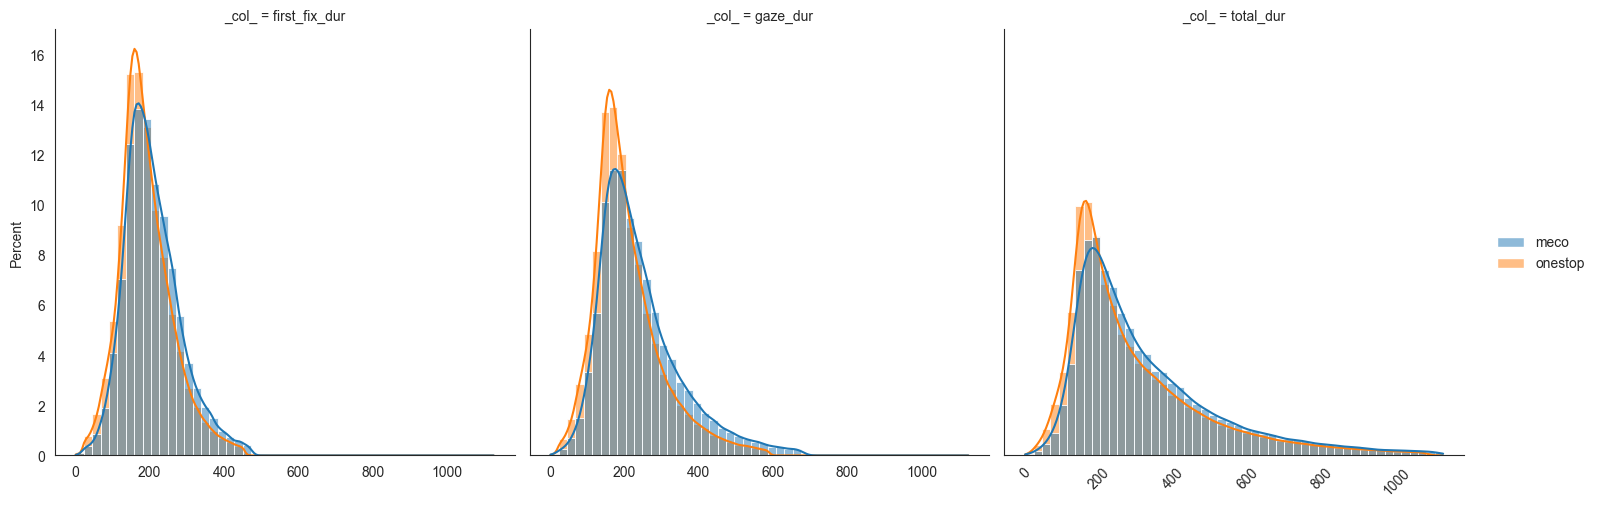

<Figure size 640x480 with 0 Axes>

In [35]:
# Plot Reading times distributions

DV = ['first_fix_dur', 'gaze_dur', 'total_dur']

values, eye_movs, corpora = [], [],[]

for corpus in ['meco', 'onestop']:
    eye_df = pd.read_csv(f'../data/processed/{corpus}_eye_mov.csv')
    eye_df.replace('.', np.nan, inplace=True)
    eye_df = eye_df.dropna(subset=['first_fix_dur','gaze_dur','total_dur'])
    eye_df['gaze_dur'] = eye_df['gaze_dur'].astype(int)
    eye_df['first_fix_dur'] = eye_df['first_fix_dur'].astype(int)
    eye_df['total_dur'] = eye_df['total_dur'].astype(int)
    for eye_mov_measure in DV:
        # remove outliers beyond 3 standard deviations
        z_scores = (eye_df[eye_mov_measure] - eye_df[eye_mov_measure].mean()) / eye_df[eye_mov_measure].std()
        eye_df_no_outliers = eye_df[np.abs(z_scores) < 3]
        values.extend(eye_df_no_outliers[eye_mov_measure].values)
        eye_movs.extend([eye_mov_measure for i in range(len(eye_df_no_outliers))])
        corpora.extend([corpus for i in range(len(eye_df_no_outliers))])

sns.displot(x=values, hue=corpora, col=eye_movs, bins=50, kde=True, stat="percent", common_norm=False)
plt.xticks(rotation=45)
plt.savefig(f'../data/analysis/reading_time_dist.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

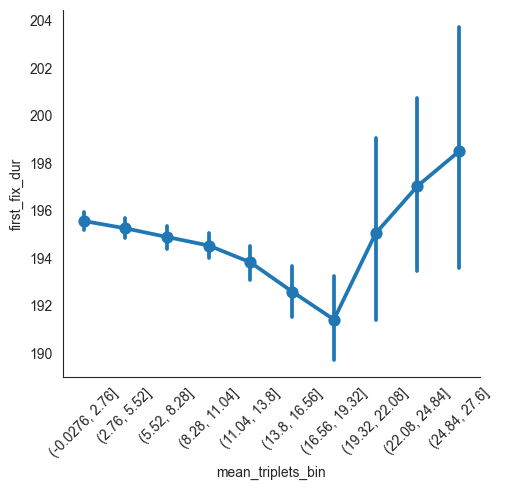

<Figure size 640x480 with 0 Axes>

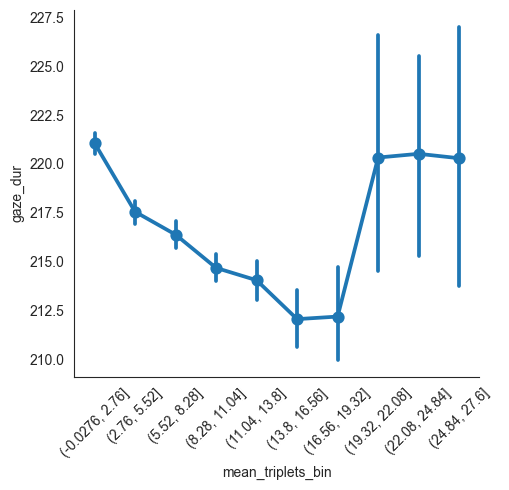

<Figure size 640x480 with 0 Axes>

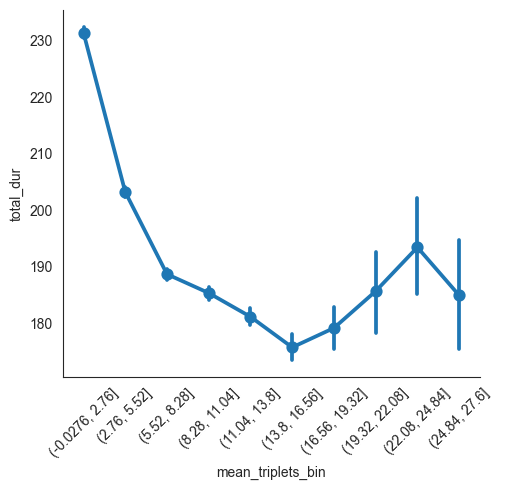

<Figure size 640x480 with 0 Axes>

In [53]:
# Number of triplets x reading times
n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_eye_mov_plus_triplets_{model}.csv')
# convert to numeric, coerce errors to NaN
df['first_fix_dur'] = pd.to_numeric(df['first_fix_dur'], errors='coerce')
df['gaze_dur'] = pd.to_numeric(df['gaze_dur'], errors='coerce')
grouped = df.groupby(['participant_id','text_id', 'ianum']).agg(mean_triplets=('n_triplets', 'mean'),
                                                                first_fix_dur=('first_fix_dur','mean'),
                                                                gaze_dur=('gaze_dur','mean'),
                                                                total_dur=('total_dur','mean')).reset_index()
for reading_measure in ['first_fix_dur','gaze_dur','total_dur']:
    grouped['mean_triplets_bin'] = pd.cut(grouped['mean_triplets'], bins=10)
    graph = sns.catplot(grouped, x='mean_triplets_bin', y=reading_measure, kind="point")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../data/analysis/{model}/{corpus}/n_triplets_{reading_measure}.png', dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.clf()

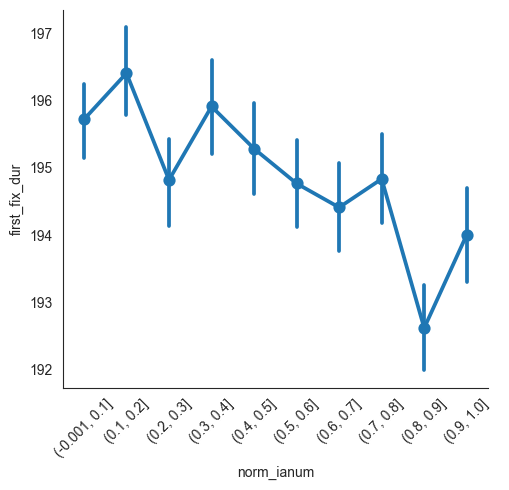

<Figure size 640x480 with 0 Axes>

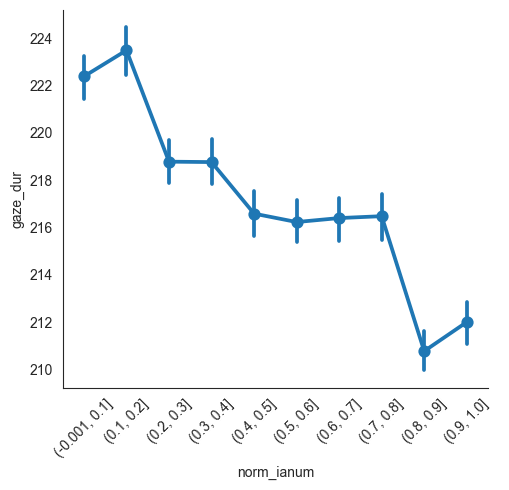

<Figure size 640x480 with 0 Axes>

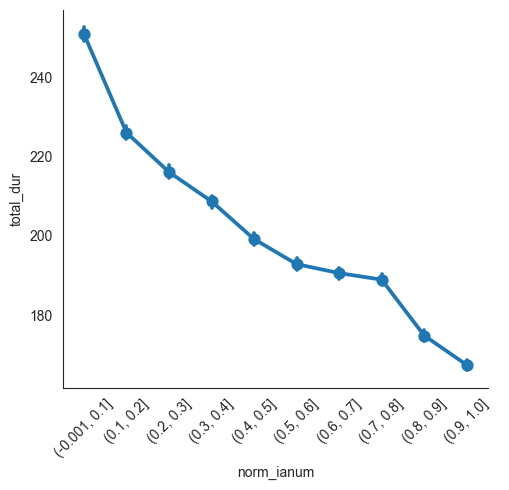

<Figure size 640x480 with 0 Axes>

In [72]:
# word position x reading times
n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'
IV = 'norm_ianum'

# # convert to numeric, coerce errors to NaN
# df['first_fix_dur'] = pd.to_numeric(df['first_fix_dur'], errors='coerce')
# df['gaze_dur'] = pd.to_numeric(df['gaze_dur'], errors='coerce')

for reading_measure in ['first_fix_dur','gaze_dur','total_dur']:
    df = pd.read_csv(f'../data/processed/{corpus}_eye_mov.csv')
    df[reading_measure] = pd.to_numeric(df[reading_measure], errors='coerce')
    df[IV] = pd.cut(df[IV], bins=10)
    graph = sns.catplot(df, x=IV, y=reading_measure, kind="point")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../data/analysis/{model}/{corpus}/{IV}_{reading_measure}.png', dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.clf()

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3027782875.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby(f'{word_pos}_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))


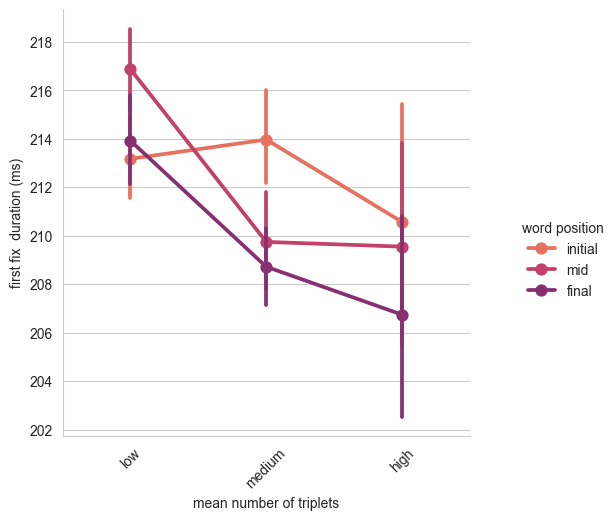

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3027782875.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby(f'{word_pos}_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))


<Figure size 640x480 with 0 Axes>

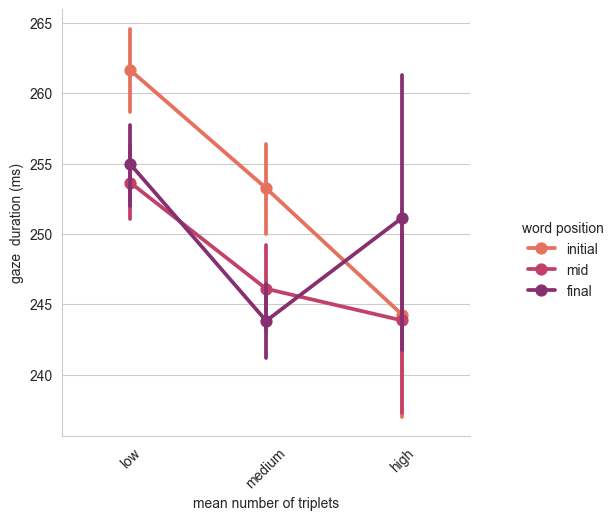

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3027782875.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby(f'{word_pos}_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))


<Figure size 640x480 with 0 Axes>

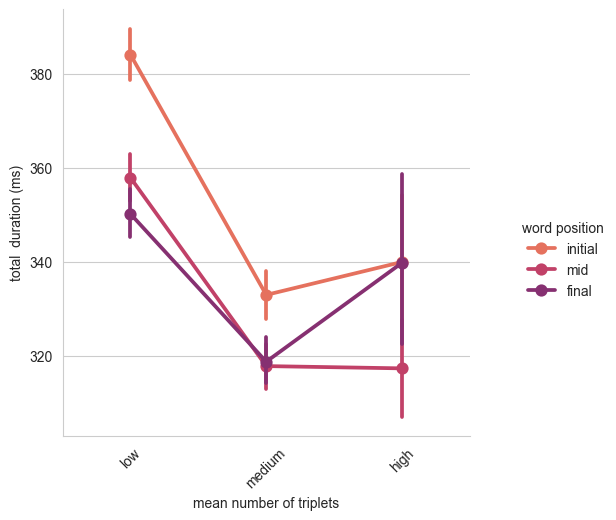

<Figure size 640x480 with 0 Axes>

In [95]:
# Reading times change as a function of n of triplets and word position in text
n_runs = 10
corpus = 'meco'
model = 'gpt-4o-mini'
word_pos = 'norm_word_pos'

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_eye_mov_plus_triplets_{model}.csv')
df['first_fix_dur'] = pd.to_numeric(df['first_fix_dur'], errors='coerce')
df['gaze_dur'] = pd.to_numeric(df['gaze_dur'], errors='coerce')
grouped = df.groupby(['participant_id','text_id', 'ianum',word_pos]).agg(mean_triplets=('n_triplets', 'mean'),
                                                                            first_fix_dur=('first_fix_dur','mean'),
                                                                            gaze_dur=('gaze_dur','mean'),
                                                                            total_dur=('total_dur','mean')).reset_index()
sns.set_style('whitegrid')

for reading_measure in ['first_fix_dur', 'gaze_dur', 'total_dur']:
    # bin normalized ianum positions
    # initial = (-0.001, 0.333], mid = (0.333, 0.667], final = (0.667, 1.0]
    grouped[f'{word_pos}_bin'] = pd.cut(grouped[word_pos], bins=3, labels=["initial", "mid", "final"])
    # bin mean triplets
    # grouped['mean_triplets_bin'] = pd.cut(grouped['mean_triplets'], bins=5, labels=['low','mid-low','mid','mid-high','high'])
    # bin mean triplets within each ianum bin (such that each word position bin has low, medium and high number of triplets, even though the actual number of triplets may differ across word position bins)
    # MECO initial: [(-0.0097, 3.233], (3.233, 6.467], (6.467, 9.7]], medium: [(4.185, 9.167], (9.167, 14.133], (14.133, 19.1]], final: [(9.479, 16.633], (16.633, 23.767], (23.767, 3...]]
    grouped['mean_triplets_bin'] = grouped.groupby(f'{word_pos}_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
    graph = sns.catplot(grouped, x='mean_triplets_bin', y=reading_measure, hue=f'{word_pos}_bin', kind="point", palette="flare")
    graph._legend.set_title("word position")
    plt.ylabel(reading_measure.replace('_', ' ').replace('dur',' duration (ms)'))
    plt.xlabel('mean number of triplets')
    plt.xticks(rotation=45)
    plt.savefig(f'../data/analysis/{model}/{corpus}/n_triplets_{word_pos}_{reading_measure}.png', dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.clf()

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  graph = sns.heatmap(grouped.pivot_table(index='mean_triplets_bin', columns='norm_ianum_bin', values=reading_measure, aggfunc='mean'), cmap='coolwarm')


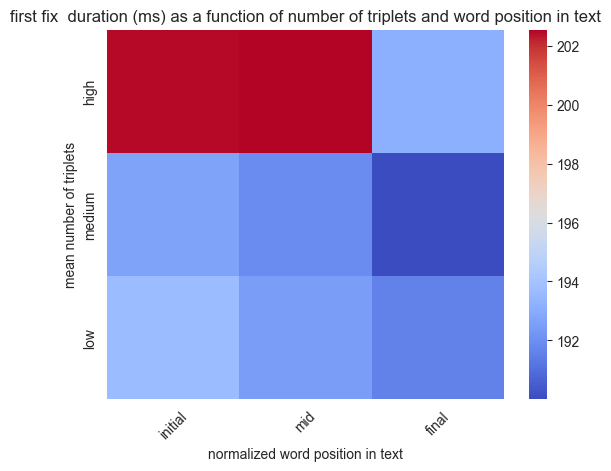

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  graph = sns.heatmap(grouped.pivot_table(index='mean_triplets_bin', columns='norm_ianum_bin', values=reading_measure, aggfunc='mean'), cmap='coolwarm')


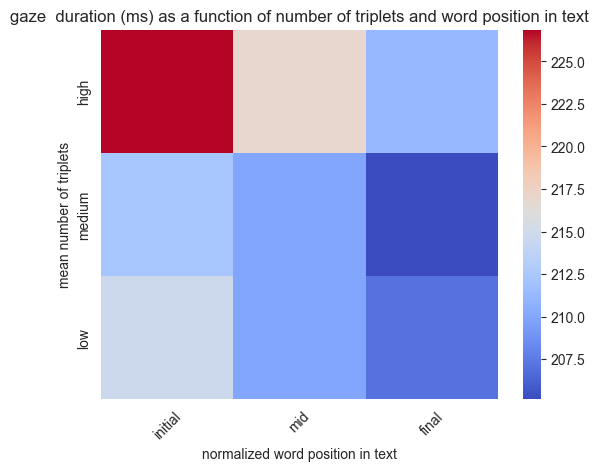

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/3499300678.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  graph = sns.heatmap(grouped.pivot_table(index='mean_triplets_bin', columns='norm_ianum_bin', values=reading_measure, aggfunc='mean'), cmap='coolwarm')


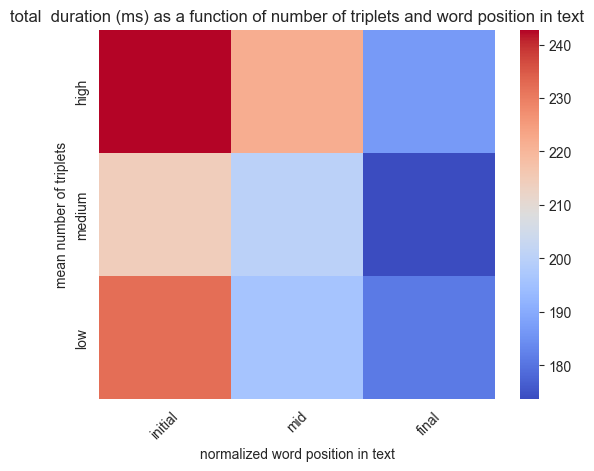

<Figure size 640x480 with 0 Axes>

In [44]:
# Heatmap of reading times by word position in text and number of triplets
n_runs = 10
corpus = 'onestop'
model = 'gpt-4o-mini'

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_eye_mov_plus_triplets_{model}.csv')
df['first_fix_dur'] = pd.to_numeric(df['first_fix_dur'], errors='coerce')
df['gaze_dur'] = pd.to_numeric(df['gaze_dur'], errors='coerce')
grouped = df.groupby(['text_id', 'ianum','norm_ianum']).agg(mean_triplets=('n_triplets', 'mean'),
                                                            first_fix_dur=('first_fix_dur','mean'),
                                                            gaze_dur=('gaze_dur','mean'),
                                                            total_dur=('total_dur','mean')).reset_index()

for reading_measure in ['first_fix_dur', 'gaze_dur', 'total_dur']:
    grouped['norm_ianum_bin'] = pd.cut(grouped['norm_ianum'], bins=3, labels=["initial", "mid", "final"])
    grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
    graph = sns.heatmap(grouped.pivot_table(index='mean_triplets_bin', columns='norm_ianum_bin', values=reading_measure, aggfunc='mean'), cmap='coolwarm')
    graph.invert_yaxis()
    plt.ylabel('mean number of triplets')
    plt.xlabel('normalized word position in text')
    plt.title(f"{reading_measure.replace('_', ' ').replace('dur',' duration (ms)')} as a function of number of triplets and word position in text")
    plt.xticks(rotation=45)
    plt.savefig(f'../data/analysis/{model}/{corpus}/heatmap_n_triplets_norm_ianum_{reading_measure}.png', dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.clf()

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_72617/2604946495.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))


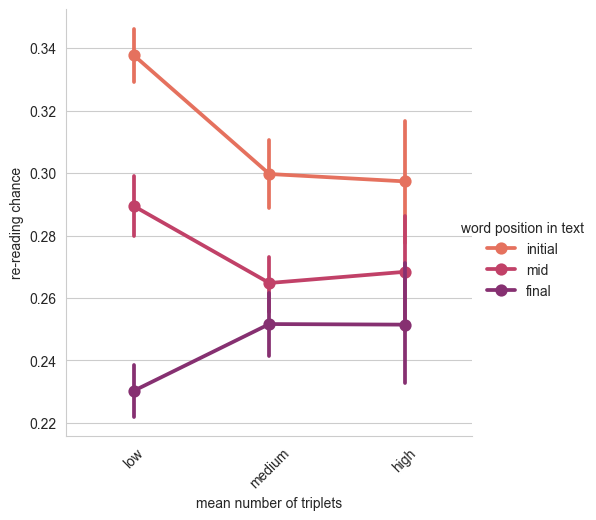

<Figure size 640x480 with 0 Axes>

In [42]:
# Rereading chance changes as a function of n of triplets and word position in text
n_runs = 10
corpus = 'meco'
model = 'gpt-4o-mini'

df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_eye_mov_plus_triplets_{model}.csv')
grouped = df.groupby(['participant_id','text_id', 'ianum','norm_ianum']).agg(mean_triplets=('n_triplets', 'mean'),
                                                                            reread_chance=('reread','mean')).reset_index()
sns.set_style('whitegrid')

# bin normalized ianum positions
# initial = (-0.001, 0.333]
# mid = (0.333, 0.667]
# final = (0.667, 1.0]
grouped['norm_ianum_bin'] = pd.cut(grouped['norm_ianum'], bins=3, labels=["initial", "mid", "final"])
# bin mean triplets
# grouped['mean_triplets_bin'] = pd.cut(grouped['mean_triplets'], bins=5, labels=['low','mid-low','mid','mid-high','high'])
# bin mean triplets within each ianum bin (such that each word position bin has low, medium and high number of triplets, even though the actual number of triplets may differ across word position bins)
# initial: [(-0.0097, 3.233], (3.233, 6.467], (6.467, 9.7]]
# medium: [(4.185, 9.167], (9.167, 14.133], (14.133, 19.1]]
# final: [(9.479, 16.633], (16.633, 23.767], (23.767, 3...]]
grouped['mean_triplets_bin'] = grouped.groupby('norm_ianum_bin')['mean_triplets'].transform(lambda x: pd.cut(x, bins=3, labels=['low', 'medium','high']))
graph = sns.catplot(grouped, x='mean_triplets_bin', y='reread_chance', hue='norm_ianum_bin', kind="point", palette="flare")
graph._legend.set_title("word position in text")
plt.ylabel('re-reading chance')
plt.xlabel('mean number of triplets')
plt.xticks(rotation=45)
plt.savefig(f'../data/analysis/{model}/{corpus}/n_triplets_norm_ianum_reread.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

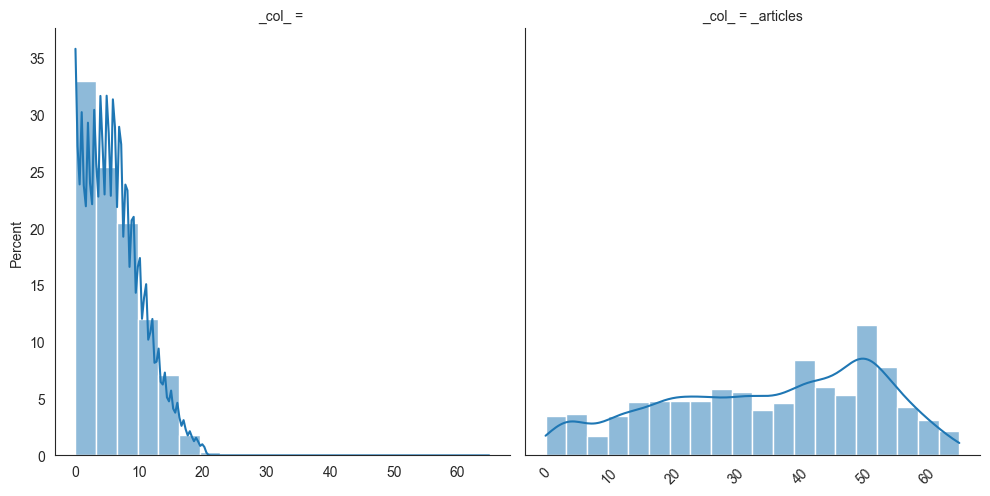

<Figure size 640x480 with 0 Axes>

In [281]:
# check distribution of number of triplets onestop articles vs. onestop paragraphs

n_runs = 10
levels, runs, number_triplets = [], [], []

for level in ['', '_articles']:

    df = pd.read_csv(f'../data/output/gpt-4o-mini/onestop/onestop{level}_words_plus_triplets_gpt-4o-mini.csv')

    for run in range(n_runs):
        df_run = df[df['run_id'] == run]
        # remove outliers beyond 3 standard deviations
        z_scores = (df_run['n_triplets'] - df_run['n_triplets'].mean()) / df_run['n_triplets'].std()
        df_no_outliers = df_run[np.abs(z_scores) < 3]
        number_triplets.extend(df_no_outliers['n_triplets'].values)
        levels.extend([level for i in range(len(df_no_outliers))])
        runs.extend([run for i in range(len(df_no_outliers))])

sns.displot(x=number_triplets, col=levels, bins=20, kde=True, stat="percent", common_norm=False)
plt.xticks(rotation=45)
plt.savefig(f'../data/analysis/n_triplets_dist.png', dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.clf()

In [ ]:
# output_word_run_filepath = f'../data/output/{MODEL}/{CORPUS}/{CORPUS}_words_plus_triplets_{MODEL}.csv'
# all_rows = pd.read_csv(output_word_run_filepath)
# if text_type == '_articles':
#     prev_article_id = None
#     prev_paragraph_id = None
#     prev_run_id = None
#
#     for i in range(len(all_rows)):
#         current_run_id = all_rows.loc[i, 'run_id']
#         current_article_id = all_rows.loc[i, 'article_text_id']
#         current_paragraph_id = all_rows.loc[i, 'paragraph_id']
#         # make sure all subsequent words in same paragraph get addition of triplets
#         if prev_run_id == current_run_id and prev_article_id == current_article_id and prev_paragraph_id != current_paragraph_id:
#             addition = all_rows.loc[i - 1, 'n_triplets']
#             for next_i in range(i, len(all_rows)):
#                 if (all_rows.loc[next_i, 'run_id'] == current_run_id) and (all_rows.loc[next_i, 'article_text_id'] == current_article_id) and (all_rows.loc[next_i, 'paragraph_id'] == current_paragraph_id):
#                     all_rows.loc[next_i, 'n_triplets'] += addition
#                 else:
#                     break
#         prev_article_id = current_article_id
#         prev_paragraph_id = current_paragraph_id
#         prev_run_id = current_run_id
#     all_rows.to_csv(output_word_run_filepath.replace('.csv','_test.csv'), index=False)
# words_df = pd.read_csv(f'../data/output/{MODEL}/{CORPUS}/{CORPUS}_words_plus_triplets_{MODEL}_test.csv')
# eye_df = pd.read_csv(f'../data/processed/{CORPUS}_eye_mov.csv')
# df = pd.merge(eye_df, words_df[
#                     ['article_text_id', 'ianum', 'triplets', 'n_triplets', 'run_id']],
#                               how='left', on=['article_text_id', 'ianum'])
# df.to_csv(f'../data/output/{MODEL}/{CORPUS}/{CORPUS}_eye_mov_plus_triplets_{MODEL}_test.csv', index=False)